# Prediction of the temperature field of a forced convection flow by a neural network

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

We start by simulating a 2D temperature field that mimics a simplified CFD-like behavior. The function `generate_field(v, Tw, mu, nx=32, ny=32)` builds a field $T(x, y)$ on a $32 \times 32$ grid. We first create a uniform mesh: $x, y \in [0, 1]$ and then form the 2D coordinates: $(X, Y) = \text{meshgrid}(x, y)$. We define a vertical temperature gradient:
$$
\text{base} = T_w \cdot (1 - Y)
$$
meaning the bottom is hot ($Y = 0$) and the top is cooler ($Y = 1$). To add convection effects depending on the flow velocity $v$:
$$
\text{conv} = \sin(\pi X v) \cdot e^{-Yv/2}
$$
which introduces horizontal oscillations that decay vertically. A viscosity term is then added to simulate diffusion effects:
$$
\text{visc} = e^{-50\mu (X^2 + Y^2)}
$$
causing the temperature to decrease radially with higher viscosity. The final temperature field combines these effects:

$$
\boxed{T = \text{base} \times (1 + 0.2 \cdot \text{conv}) \times \text{visc}}
$$
so the resulting pattern has a strong vertical gradient, small convective perturbations, and smooth viscous damping. Then we generate a dataset of $500$ samples, each with random physical parameters:
$$
v \sim \mathcal{U}(0.1, 2.0), \quad T_w \sim \mathcal{U}(300, 800), \quad \mu \sim \mathcal{U}(0.001, 0.01)
$$

For each sample, we store the triplet $(v, T_w, \mu)$ in `params` and the corresponding 2D field $T(x,y)$ in `fields`. In the end, `params` is a $500 \times 3$ matrix of input parameters, and `fields` is a $500 \times 32 \times 32$ tensor of generated temperature maps.

In [6]:
def generate_field(v, Tw, mu, nx=32, ny=32):
    x = np.linspace(0, 1, nx)
    y = np.linspace(0, 1, ny)
    X, Y = np.meshgrid(x, y)

    # "CFD type" temperature field
    base = Tw * (1 - Y)  # vertical gradient
    conv = np.sin(np.pi * X * v) * np.exp(-Y * v / 2)
    visc = np.exp(-mu * (X**2 + Y**2) * 50)
    T = base * (1 + 0.2 * conv) * visc
    return T

# Dataset generation
n_samples = 500
params = np.zeros((n_samples, 3))
fields = np.zeros((n_samples, 32, 32))

for i in range(n_samples):
    v = np.random.uniform(0.1, 2.0)
    Tw = np.random.uniform(300, 800)
    mu = np.random.uniform(0.001, 0.01)
    params[i] = [v, Tw, mu]
    fields[i] = generate_field(v, Tw, mu)

Here we show an example of one of the generated temperature fields :   

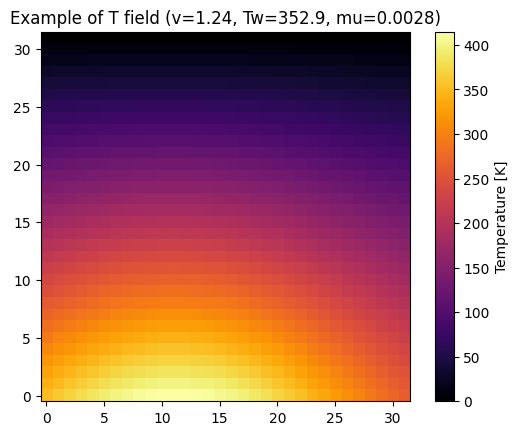

In [7]:
plt.imshow(fields[0], origin='lower', cmap='inferno')
plt.title(f"Example of T field (v={params[0,0]:.2f}, Tw={params[0,1]:.1f}, mu={params[0,2]:.4f})")
plt.colorbar(label='Temperature [K]')
plt.show()

We define a custom PyTorch dataset to handle the generated temperature fields and their physical parameters. We start by creating the class `FlowDataset(Dataset)`, which allows us to store the data in a format compatible with PyTorch’s `DataLoader`. Inside the constructor, we convert the NumPy arrays into tensors:
$$
x = \text{parameters} = (v, T_w, \mu)
$$
$$
y = \text{temperature fields } T(x, y)
$$
We write:
```python
self.x = torch.tensor(params, dtype=torch.float32)
self.y = torch.tensor(fields, dtype=torch.float32).unsqueeze(1)

In [8]:
class FlowDataset(Dataset):
    def __init__(self, params, fields):
        # Param inputs
        self.x = torch.tensor(params, dtype=torch.float32)
        # Field output
        self.y = torch.tensor(fields, dtype=torch.float32).unsqueeze(1)  # add channel

    def __len__(self):
        return len(self.x) # total number of samples

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx] # retrieves a sample

# train_test_split ---> 80% training data, 20% test data
X_train, X_test, Y_train, Y_test = train_test_split(params, fields, test_size=0.2, random_state=42)
train_data = FlowDataset(X_train, Y_train)
test_data = FlowDataset(X_test, Y_test)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

We define two neural network architectures: an **Autoencoder** that learns to compress and reconstruct temperature fields, and a **ParamToLatent** network that predicts the latent representation from physical parameters.

We start with the class `Autoencoder(nn.Module)`.  
An autoencoder consists of two parts: an **encoder** and a **decoder**.

The **encoder** transforms the input field $x \in \mathbb{R}^{1 \times 32 \times 32}$ into a low-dimensional latent vector $z \in \mathbb{R}^{d_z}$.  
Mathematically:
$$
z = f_{\text{enc}}(x; \theta_e)
$$
where $\theta_e$ are the encoder’s parameters.

In code, the encoder uses convolutional layers to progressively reduce spatial resolution. A step by step explanation is given below.

- Step 1: <span style="color:blue">**Encoder Input**</span>  
  Input temperature field (it is a scalar (so $1$) defined on a $32$ by $32$ grid) $$T(x,y) \in \mathbb{R}^{1\times32\times32}$$

- Step 2: <span style="color:blue">**Conv Layer 1**</span>  
  $$
  h_1 = \text{ReLU}(\text{Conv2d}(T, 8, 3, stride=2, padding=1)) \quad \Rightarrow 8\times16\times16
  $$

- Step 3: <span style="color:blue">**Conv Layer 2**</span>  
  $$
  h_2 = \text{ReLU}(\text{Conv2d}(h_1, 16, 3, stride=2, padding=1)) \quad \Rightarrow 16\times8\times8
  $$

- Step 4: <span style="color:blue">**Flatten & Linear**</span>  
  Flatten and project to latent space:  
  $$
  z_T = \text{Linear}(\text{Flatten}(h_2)) \in \mathbb{R}^{16}
  $$

- Step 5: <span style="color:green">**ParamToLatent Input**</span>  
  Input parameters: $$(\mu, v, T_w) \in \mathbb{R}^3$$

- Step 6: <span style="color:green">**ParamToLatent Network**</span>  
  Project parameters to latent space:  
  $$
  z_p = \text{Linear}(\text{ReLU}(\text{Linear}(\text{ReLU}(\text{Linear}([\mu,v,T_w],64)),64)),16)
  $$

- Step 7: <span style="color:orange">**Decoder Linear**</span>  
  Map latent vector $$z_T$$ back to a flattened tensor:  
  $$
  h_3 = \text{ReLU}(\text{Linear}(z_T, 1024)) \quad \Rightarrow 16\times8\times8
  $$

- Step 8: <span style="color:orange">**ConvTranspose Layer 1**</span>  
  $$
  h_4 = \text{ReLU}(\text{ConvTranspose2d}(h_3, 8, 3, stride=2, padding=1, output\_padding=1)) \quad \Rightarrow 8\times16\times16
  $$

- Step 9: <span style="color:orange">**ConvTranspose Layer 2**</span>  
  $$
  \hat{T} = \text{ConvTranspose2d}(h_4, 1, 3, stride=2, padding=1, output\_padding=1) \quad \Rightarrow 1\times32\times32
  $$

- Step 10: <span style="color:purple">**Losses**</span>  
  - Reconstruction of temperature field:  
    $$
    \mathcal{L}_{AE} = \| T - \hat{T} \|_2^2
    $$  
  - Alignment of latent vectors:  
    $$
    \mathcal{L}_{param} = \| z_p - z_T \|_2^2
    $$

- **Linear Layer** (`Linear(n, m)`): performs a linear transformation of the input vector.  
  $$
  y = W x + b, \quad W \in \mathbb{R}^{m \times n},\ b \in \mathbb{R}^m
  $$  
  It maps an input of size $n$ to an output of size $m$ (this is the parameters of Linear()).

- **ReLU Activation** (`ReLU`): introduces non-linearity by applying  
  $$
  \text{ReLU}(x_i) = \max(0, x_i)
  $$  
  element-wise to the input vector.

<div style="color:gray; font-size:0.9em;">
Note: Linear layers alone can only perform linear transformations. ReLU allows the network to model complex, non-linear relationships.
</div>

![Scheme of a autoencoder](autoencoder_scheme.png)

We can represent the autoencoder as a seven-layer neural network, where the first three layers act as the encoder, progressively compressing the input temperature field into a compact latent representation at the bottleneck (fourth layer). The remaining three layers serve as the decoder, expanding this latent vector back into a reconstructed version of the original input. Because the real network involves thousands of neurons (due to convolutional operations on 32×32 grids), a scaling factor was applied to reduce the number of neurons per layer. This simplification preserves the relative proportions between layers and clearly illustrates the encoder–latent–decoder structure without overloading the graphical representation :

![Scheme of a autoencoder in NN representation](neural_network_autoencoder.png)

In [9]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(16 * 8 * 8, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16 * 8 * 8),
            nn.ReLU(),
            nn.Unflatten(1, (16, 8, 8)),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(8, 1, 3, stride=2, padding=1, output_padding=1)
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out, z


class ParamToLatent(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
    def forward(self, x): return self.net(x)

We create an instance of the autoencoder with `ae = Autoencoder()`.  
We define an Adam optimizer to update the network parameters $\theta = (\theta_e, \theta_d)$ using
$$
\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}_{\text{rec}}
$$
with learning rate $\eta = 10^{-3}$.  
We choose mean squared error as the loss function:
$$
\mathcal{L}_{\text{rec}} = \frac{1}{N} \sum_{i=1}^N \| y_i - \hat{y}_i \|_2^2
$$
which measures the difference between the input field $y$ and its reconstruction $\hat{y}$.

We then train the autoencoder for 20 epochs. On each epoch, we set the model to training mode with `ae.train()`.  
For each batch of temperature fields $y$ from `train_loader`, we:

- reset the gradients with `optimizer.zero_grad()`,
- compute the reconstructed field $\hat{y} = f_{\text{dec}}(f_{\text{enc}}(y))$ and latent vector $z$,
- calculate the reconstruction loss $\mathcal{L}_{\text{rec}}(y, \hat{y})$,
- backpropagate the gradients using `loss.backward()`,
- update the network parameters with `optimizer.step()`,
- accumulate the batch loss to monitor training progress.

After all batches, we print the average loss over the epoch.  
As training progresses, the loss
$$
\mathcal{L}_{\text{rec}}
$$
should decrease, indicating that the autoencoder is learning to compress and reconstruct the temperature fields accurately.

In [10]:
ae = Autoencoder()
optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(20):
    ae.train()
    total_loss = 0
    for _, y in train_loader:
        optimizer.zero_grad()
        y_pred, _ = ae(y)
        loss = loss_fn(y_pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/20, loss={total_loss/len(train_loader):.4f}")

Epoch 1/20, loss=87943.5919
Epoch 2/20, loss=57685.4357
Epoch 3/20, loss=34625.4965
Epoch 4/20, loss=16090.3169
Epoch 5/20, loss=7863.8274
Epoch 6/20, loss=4015.9074
Epoch 7/20, loss=2671.3595
Epoch 8/20, loss=2047.4122
Epoch 9/20, loss=1720.5562
Epoch 10/20, loss=1499.9343
Epoch 11/20, loss=1363.6717
Epoch 12/20, loss=1236.2619
Epoch 13/20, loss=1136.9770
Epoch 14/20, loss=1063.5355
Epoch 15/20, loss=992.7165
Epoch 16/20, loss=939.1054
Epoch 17/20, loss=897.5054
Epoch 18/20, loss=829.7189
Epoch 19/20, loss=781.6619
Epoch 20/20, loss=713.1812


We set the autoencoder to evaluation mode with `ae.eval()` to disable dropout and batch normalization.  
We initialize empty lists `X_latent` and `Y_latent` to store physical parameters and their corresponding latent vectors.  

Using `torch.no_grad()`, we loop over the training data to compute latent representations without computing gradients:
$$
z = f_{\text{enc}}(y)
$$
For each batch, we append the parameters $x$ to `X_latent` and the latent vectors $z$ to `Y_latent`.  
After the loop, we concatenate all batches:
$$
X_{\text{latent}} = \text{torch.cat}(X_{\text{latent}}), \quad
Y_{\text{latent}} = \text{torch.cat}(Y_{\text{latent}})
$$

We then define the `ParamToLatent` network `mlp`, which maps physical parameters to latent vectors:
$$
z_p = f_{\text{param}}(x; \theta_p)
$$
We create an Adam optimizer and MSE loss:
$$
\mathcal{L}_{\text{MLP}} = \frac{1}{N} \sum_{i=1}^N \| z_{p,i} - z_i \|_2^2
$$

We train for 100 epochs. On each epoch, we:

- reset gradients with `opt_mlp.zero_grad()`,
- predict latent vectors from parameters: `z_pred = mlp(X_latent)`,
- compute the MSE loss between predicted and autoencoder latent vectors,
- backpropagate: `loss.backward()`,
- update parameters: `opt_mlp.step()`.

Every 10 epochs, we print the loss to monitor training progress.  
As training progresses, the loss
$$
\mathcal{L}_{\text{MLP}}
$$
should decrease, indicating that the MLP is learning to predict the latent code from physical parameters accurately.

In [11]:
ae.eval()
X_latent, Y_latent = [], []
with torch.no_grad():
    for x, y in train_loader:
        _, z = ae(y)
        X_latent.append(x)
        Y_latent.append(z)
X_latent = torch.cat(X_latent)
Y_latent = torch.cat(Y_latent)

mlp = ParamToLatent()
opt_mlp = torch.optim.Adam(mlp.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(100):
    opt_mlp.zero_grad()
    z_pred = mlp(X_latent)
    loss = loss_fn(z_pred, Y_latent)
    loss.backward()
    opt_mlp.step()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/100, loss={loss.item():.4e}")

Epoch 10/100, loss=8.2645e+05
Epoch 20/100, loss=7.3552e+05
Epoch 30/100, loss=6.0870e+05
Epoch 40/100, loss=4.4468e+05
Epoch 50/100, loss=2.6727e+05
Epoch 60/100, loss=1.2706e+05
Epoch 70/100, loss=6.2068e+04
Epoch 80/100, loss=4.1097e+04
Epoch 90/100, loss=2.5582e+04
Epoch 100/100, loss=1.6894e+04


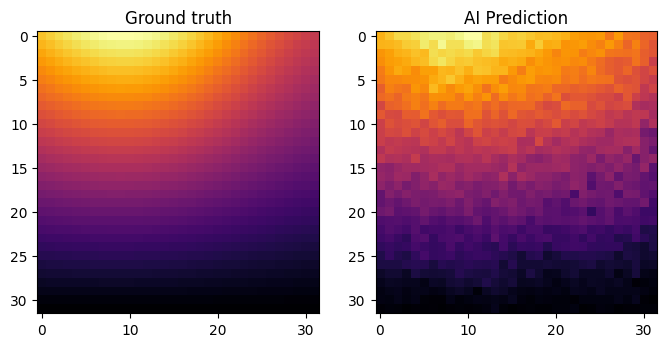

In [12]:
idx = 3
x_test = torch.tensor(X_test[idx], dtype=torch.float32).unsqueeze(0)
y_true = Y_test[idx]

with torch.no_grad():
    z_pred = mlp(x_test)
    y_pred = ae.decoder(z_pred).squeeze().numpy()

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(y_true, cmap='inferno')
plt.title("Ground truth")
plt.subplot(1,2,2)
plt.imshow(y_pred, cmap='inferno')
plt.title("AI Prediction")
plt.show()

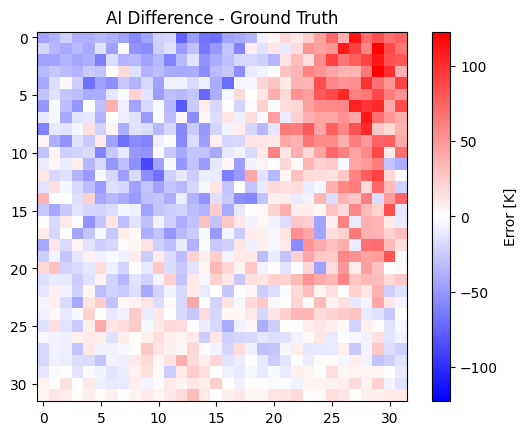

In [13]:
plt.imshow(y_pred - y_true, cmap='bwr', vmin=-np.max(np.abs(y_pred - y_true)), vmax=np.max(np.abs(y_pred - y_true)))
plt.colorbar(label='Error [K]')
plt.title("AI Difference - Ground Truth")
plt.show()

In [14]:
mse = np.mean((y_pred - y_true)**2)
print(f"MSE = {mse:.4f}")

nrmse = np.sqrt(mse) / (np.max(y_true) - np.min(y_true))
print(f"NRMSE = {nrmse:.4f}")

r2 = r2_score(y_true.flatten(), y_pred.flatten())
print(f"R² = {r2:.4f}")

MSE = 1138.0912
NRMSE = 0.0438
R² = 0.9731


The results show the performance of the model in reconstructing temperature fields from the latent representation predicted by the MLP:

- The **mean squared error (MSE)** is 1138.091 This represents the average squared difference between the predicted and true temperature values:
$$
\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$
A lower MSE indicates better reconstruction quality.

- The **normalized root mean squared error (NRMSE)** is 0.0438. This scales the RMSE relative to the range or mean of the data:
$$
\text{NRMSE} = \frac{\sqrt{\text{MSE}}}{y_\text{max} - y_\text{min}}
$$
A value of ~0.04 means the **typical error is about 4% of the data range**, which indicates a good accurate prediction.

- The **coefficient of determination $R^2$ is 0.9731**. This measures the proportion of variance in the true data explained by the predictions:
$$
R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}
$$
An $R^2$ close to 1 indicates that the model captures most of the variability of the data, showing strong predictive performance.

Overall, these metrics suggest that the MLP (Multi-Layer Perceptron) combined with the autoencoder latent space provides accurate reconstructions of the temperature fields, with low relative error and high explained variance.

In [15]:
%whos

Variable           Type             Data/Info
---------------------------------------------
Autoencoder        type             <class '__main__.Autoencoder'>
DataLoader         type             <class 'torch.utils.data.dataloader.DataLoader'>
Dataset            type             <class 'torch.utils.data.dataset.Dataset'>
FlowDataset        type             <class '__main__.FlowDataset'>
ParamToLatent      type             <class '__main__.ParamToLatent'>
Tw                 float            573.6311566252289
X_latent           Tensor           tensor([[8.3747e-01, 4.58<...>7.3362e+02, 3.1919e-03]])
X_test             ndarray          100x3: 300 elems, type `float64`, 2400 bytes
X_train            ndarray          400x3: 1200 elems, type `float64`, 9600 bytes
Y_latent           Tensor           tensor([[  909.9637, -131<...>,\n          -938.0645]])
Y_test             ndarray          100x32x32: 102400 elems, type `float64`, 819200 bytes (800.0 kb)
Y_train            ndarray          400